📉 TỐC ĐỘ SUY GIẢM INPUT THỰC TẾ (%/tháng):
   -> Annulus pressure_avg: 0.20%/tháng
   -> Buffer pressure_avg: 0.31%/tháng
   -> T_avg: 0.69%/tháng
   -> Flow pressure_avg: 0.39%/tháng


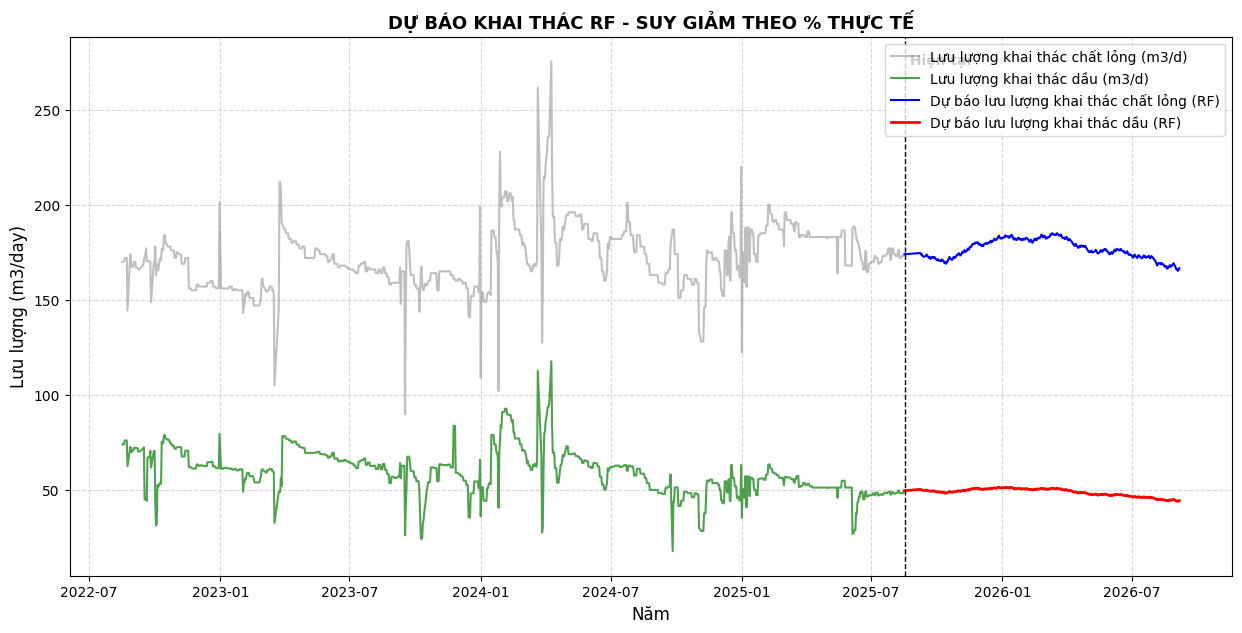


KẾT QUẢ DỰ BÁO CHI TIẾT THEO THÁNG (AVERAGE)
            Qliq_Forecast  Qoil_Forecast     OilCut
Date                                               
2025-09-30     172.796363      49.649818  28.732932
2025-10-31     171.261936      48.870562  28.535884
2025-11-30     177.187810      50.176647  28.319059
2025-12-31     180.706158      50.793978  28.109084
2026-01-31     182.594825      50.939763  27.897538
2026-02-28     182.014273      50.422038  27.702413
2026-03-31     183.585217      50.501592  27.508507
2026-04-30     179.184875      48.944070  27.314376
2026-05-31     175.454287      47.585625  27.121401
2026-06-30     175.276685      47.210090  26.934504
2026-07-31     172.661232      46.184623  26.748636
2026-08-31     168.569023      44.863396  26.614186
2026-09-30     166.089221      44.191970  26.607368


/tmp/ipykernel_1022/2670150189.py:193: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_final.set_index('Date').resample('M').mean()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest

# 1. CẤU HÌNH & ĐƯỜNG DẪN
FORECAST_DURATION_DAYS = 365

DATA_FILE   = "/content/drive/MyDrive/Dữ liệu/BK_20_Test_3_clean.csv"
OILCUT_FILE = "/content/drive/MyDrive/Dữ liệu/OilCut_Forecast_3Years_1095Days.csv"
MODEL_PATH  = "/content/drive/MyDrive/Model ML/RandomForest.pkl"

FEATURE_SEQ = [
    "Gas injection rate", "Annulus pressure_avg", "Buffer pressure_avg",
    "T_avg", "Flow pressure_avg", "Choke"
]
TARGET = 'Qliq'

# Phân loại biến theo yêu cầu
AUTO_DECLINE_VARS = ['Annulus pressure_avg', 'Buffer pressure_avg', 'T_avg', 'Flow pressure_avg']
FIXED_VARS = ['Gas injection rate', 'Choke']

# 2. HÀM XỬ LÝ DỮ LIỆU
def process_data_inference(filepath):
    df = pd.read_csv(filepath)
    mapping = {
        'Annulus pressure': 'Annulus pressure_avg',
        'Buffer pressure': 'Buffer pressure_avg',
        'Flow pressure': 'Flow pressure_avg',
        'T': 'T_avg'
    }
    for raw, avg in mapping.items():
        if avg not in df.columns:
            if f'{raw} min' in df.columns and f'{raw} max' in df.columns:
                df[avg] = (df[f'{raw} min'] + df[f'{raw} max']) / 2
            elif raw in df.columns:
                df[avg] = df[raw]
    df[TARGET] = df[TARGET].ffill().bfill()
    return df

def calculate_daily_decline_from_monthly(series, lookback_days=180):
    """Tính toán tỷ lệ suy giảm mỗi ngày dựa trên xu hướng %/tháng thực tế"""
    y = series.iloc[-lookback_days:].values
    x = np.arange(len(y)).reshape(-1, 1)
    lr = LinearRegression().fit(x, y)
    current_val = y[-1]
    if current_val <= 0: return 0

    # slope là lượng thay đổi tuyệt đối mỗi ngày
    slope = lr.coef_[0]
    # monthly_rate = (lượng đổi trong 30 ngày) / giá trị hiện tại
    monthly_rate = -(slope * 30) / current_val

    # Chuyển đổi monthly_rate sang daily_rate để nhân dồn mỗi ngày
    if monthly_rate <= 0: return 0
    daily_rate = monthly_rate / 30
    return daily_rate

# 3. CHUẨN BỊ MÔ HÌNH & TỶ LỆ SUY GIẢM
df_clean = process_data_inference(DATA_FILE)
model = joblib.load(MODEL_PATH)

scalers = {var: StandardScaler().fit(df_clean[[var]]) for var in FEATURE_SEQ}
scaler_y = StandardScaler().fit(df_clean[[TARGET]])

# Tính tỷ lệ suy giảm thực tế cho từng biến áp suất/nhiệt độ
input_decline_rates = {var: calculate_daily_decline_from_monthly(df_clean[var]) for var in AUTO_DECLINE_VARS}

# Giá trị khởi tạo cho dự báo
current_sim_values = {var: df_clean[var].iloc[-1] for var in FEATURE_SEQ}
prev_val = df_clean[TARGET].iloc[-1]

# 4. VÒNG LẶP DỰ BÁO (LOGIC THỰC TẾ)
print(f"📉 TỐC ĐỘ SUY GIẢM INPUT THỰC TẾ (%/tháng):")
for var, rate in input_decline_rates.items():
    print(f"   -> {var}: {rate*30*100:.2f}%/tháng")

predicted_qliq = []
np.random.seed(999) # Giữ seed để đồng bộ nhiễu với LSTM

for i in range(FORECAST_DURATION_DAYS):
    # 1. Tạo Input DataFrame
    input_df = pd.DataFrame([current_sim_values], columns=FEATURE_SEQ)

    # 2. Scale Input
    scaled_input_df = input_df.copy()
    for var in FEATURE_SEQ:
        scaled_input_df[var] = scalers[var].transform(input_df[[var]])

    # 3. Predict (Base RF Value)
    pred_scaled = model.predict(scaled_input_df)[0]
    trend_val = scaler_y.inverse_transform([[pred_scaled]])[0][0]

    # 4. Anti-Shock (Chặn tăng vọt phi vật lý)
    if trend_val > prev_val:
        trend_val = prev_val * 0.9998 # Xu hướng giảm nhẹ thay vì đi ngang

    # 5. Thêm Nhiễu (Noise ±1 để giống độ nhám LSTM)
    noise = np.random.uniform(-1, 1)
    final_pred_val = max(0, trend_val + noise)

    predicted_qliq.append(final_pred_val)
    prev_val = final_pred_val

    # 6. CẬP NHẬT GIÁ TRỊ INPUT CHO NGÀY MAI
    # Nhóm suy giảm %
    for var in AUTO_DECLINE_VARS:
        current_sim_values[var] *= (1 - input_decline_rates[var])

    # Nhóm FIXED_VARS (Gas injection, Choke) giữ nguyên giá trị cuối cùng, không đổi.

import matplotlib.dates as mdates

# 5. XỬ LÝ OILCUT & KẾT QUẢ DỰ BÁO
df_oilcut = pd.read_csv(OILCUT_FILE)
df_oilcut['Date'] = pd.to_datetime(df_oilcut['Date'])
start_date = df_oilcut['Date'].iloc[0]
date_range = pd.date_range(start=start_date, periods=FORECAST_DURATION_DAYS)

oilcut_vals = df_oilcut.set_index('Date').reindex(date_range)['hyperbolic_pred'].interpolate().ffill().values

df_final = pd.DataFrame({
    'Date': date_range,
    'Qliq_Forecast': predicted_qliq,
    'OilCut': oilcut_vals
})
df_final['Qoil_Forecast'] = df_final['Qliq_Forecast'] * (df_final['OilCut'] / 100.0)

# 6. CHUẨN BỊ DỮ LIỆU VẼ BIỂU ĐỒ (LIỀN MẠCH)
# Lấy dữ liệu lịch sử (3 năm cuối)
df_hist = df_clean.copy()
df_hist['Date'] = pd.to_datetime(df_hist['Date'])
last_3_years = df_hist['Date'].max() - pd.DateOffset(years=3)
df_hist_plot = df_hist[df_hist['Date'] >= last_3_years].copy()

# Giả định cột Water Cut để tính Qoil lịch sử (nếu không có thì tính từ Qliq và OilCut cũ)
if 'Water cut' in df_hist_plot.columns:
    df_hist_plot['Qoil_Plot'] = df_hist_plot[TARGET] * (1 - df_hist_plot['Water cut']/100)
else:
    # Nếu không có cột water cut, tạm thời coi Qoil = Qliq * 0.2 (hoặc tỉ lệ thực tế của bạn)
    df_hist_plot['Qoil_Plot'] = df_hist_plot[TARGET] * 0.15

# Tạo điểm nối (Connection) để biểu đồ liền mạch
last_date = df_hist_plot['Date'].iloc[-1]
last_qliq = df_hist_plot[TARGET].iloc[-1]
last_qoil = df_hist_plot['Qoil_Plot'].iloc[-1]

connection_row = pd.DataFrame({
    'Date': [last_date],
    'Qliq_Forecast': [last_qliq],
    'Qoil_Forecast': [last_qoil]
})

# Kết hợp điểm nối với dữ liệu dự báo
df_forecast_plot = pd.concat([connection_row, df_final], ignore_index=True)

# 7. VẼ BIỂU ĐỒ & IN KẾT QUẢ THEO THÁNG
plt.figure(figsize=(15, 7))

# 1. Vẽ Lịch sử (3 năm cuối)
plt.plot(df_hist_plot['Date'], df_hist_plot[TARGET], color='gray', alpha=0.5, label='Lưu lượng khai thác chất lỏng (m3/d)')
plt.plot(df_hist_plot['Date'], df_hist_plot['Qoil_Plot'], color='forestgreen', alpha=0.8, label='Lưu lượng khai thác dầu (m3/d)')

# 2. Vẽ Dự báo (Nối liền từ điểm cuối lịch sử)
plt.plot(df_forecast_plot['Date'], df_forecast_plot['Qliq_Forecast'], color='blue', lw=1.5, label='Dự báo lưu lượng khai thác chất lỏng (RF)')
plt.plot(df_forecast_plot['Date'], df_forecast_plot['Qoil_Forecast'], color='red', lw=2, label='Dự báo lưu lượng khai thác dầu (RF)')

# Định dạng trục tọa độ
plt.axvline(last_date, color='black', ls='--', lw=1)
plt.text(last_date, plt.ylim()[1]*0.95, " Hiện tại", color='black', fontweight='bold', ha='left')

plt.title(f"DỰ BÁO KHAI THÁC RF - SUY GIẢM THEO % THỰC TẾ", fontsize=13, fontweight='bold')
plt.xlabel("Năm", fontsize=12)
plt.ylabel("Lưu lượng (m3/day)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Tối ưu hóa hiển thị ngày tháng
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
#plt.gcf().autofmt_xdate()

#plt.tight_layout()
plt.show()

# --- IN KẾT QUẢ DỰ BÁO TỪNG THÁNG ---
print("\n" + "="*50)
print("KẾT QUẢ DỰ BÁO CHI TIẾT THEO THÁNG (AVERAGE)")
print("="*50)
df_monthly = df_final.set_index('Date').resample('M').mean()
print(df_monthly[['Qliq_Forecast', 'Qoil_Forecast', 'OilCut']].to_string())

# Lưu file kết quả
output_path = "/content/drive/MyDrive/Dữ liệu/Forecast_RF.csv"
df_final.to_csv(output_path, index=False)